# Working Color-Image GAN Teaching Demo

This notebook is a deliberately reliable color-image GAN demo.

The earlier DCGAN smoke test ran, but its generated images were not visually close to the training-image family. That is not good enough for teaching. This version uses a simple image distribution that a GAN can learn quickly on CPU.

## Key point

A GAN does not learn to reproduce one specific training image. It learns a distribution:

$$
p_G \approx p_{\mathrm{data}}.
$$

So the generated images should look like samples from the same family as the training images, not like exact copies.

## 1. Imports

In [2]:
#!pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   --- ------------------------------------ 10.5/123.0 MB 65.1 MB/s eta 0:00:02
   --------- ------------------------------ 29.6/123.0 MB 81.6 MB/s eta 0:00:02
   --------------- ------------------------ 48.5/123.0 MB 83.3 MB/s eta 0:00:01
   --------------------- ------------------ 67.4/123.0 MB 87.6 MB/s eta 0:00:01
   ---------------------------- ----------- 87.6/123.0 MB 88.6 MB/s eta 0:00:01
   --------------------------------- ----- 107.2/123.0 MB 90.0 MB/s eta 0:00:01
   --------------------------------------  122.9/123.0 MB 91.3 MB/s eta 0:00:01
   --------------------------------------- 123.0/123.0 MB 85.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 53.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 80.0 MB/s eta 0:00:


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import math
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.set_num_threads(1)

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:", device)

PyTorch version: 2.12.1+cpu
Using device: cpu


## 2. Configuration

In [2]:
IMAGE_SIZE = 16
N_REAL = 1024
BATCH_SIZE = 64
Z_DIM = 8
TRAIN_STEPS = 400

OUTPUT_DIR = Path("working_color_gan_fast_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Image size:", IMAGE_SIZE)
print("Training steps:", TRAIN_STEPS)

Image size: 16
Training steps: 400


## 3. Plotting utilities

Images are represented in the neural network range \([-1,1]\). For plotting we use

$$
A_{\mathrm{plot}}=\frac{A+1}{2}.
$$

In [3]:
def denormalize(x):
    return (x.clamp(-1, 1) + 1.0) / 2.0


def make_grid(images, nrow=8):
    images = denormalize(images.detach().cpu())
    B, C, H, W = images.shape
    nrow = min(nrow, B)
    ncol = int(math.ceil(B / nrow))

    canvas = torch.zeros(C, ncol * H, nrow * W)

    for i in range(B):
        r = i // nrow
        c = i % nrow
        canvas[:, r*H:(r+1)*H, c*W:(c+1)*W] = images[i]

    return canvas.permute(1, 2, 0).numpy()


def show_grid(images, title, save_path=None):
    arr = make_grid(images)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(arr)
    ax.axis("off")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")

    plt.show()

## 4. Real training images

The real data distribution consists of simple colored Gaussian blobs on a dark background.

Each sample is an RGB image

$$
A\in[-1,1]^{3\times 16\times 16}.
$$

In [4]:

            [1.0, 0.10, 0.10],
            [0.10, 1.0, 0.10],
            [0.10, 0.25, 1.0],
            [1.0, 1.0, 0.10],
            [1.0, 0.10, 1.0],
            [0.10, 1.0, 1.0],

([0.1, 1.0, 1.0],)

Real batch shape: (64, 3, 16, 16)
Real displayed standard deviation: 0.18619336187839508


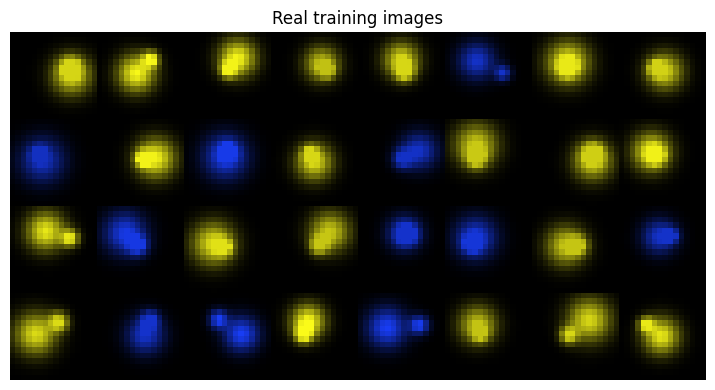

In [5]:
class ColorBlobDataset(Dataset):
    def __init__(self, n=1024, image_size=16, seed=1):
        rng = np.random.default_rng(seed)

        yy, xx = np.mgrid[0:image_size, 0:image_size].astype(np.float32)
        xx = 2.0 * xx / (image_size - 1) - 1.0
        yy = 2.0 * yy / (image_size - 1) - 1.0

        palette = np.array([
            [1.0, 1.0, 0.10],[0.10, 0.25, 1.0]
            
        ], dtype=np.float32)

        images = []

        for _ in range(n):
            color = palette[rng.integers(len(palette))]
            color = color * rng.uniform(0.75, 1.0)

            #cx, cy = rng.uniform(-0.45, 0.45, size=2)
            cx = rng.uniform(-0.45, 0.45)
            cy = rng.uniform(-0.45, 0.0)
            
            #sigma = rng.uniform(0.17, 0.30)
            sigma_1 = rng.uniform(0.12, 0.17)

            r2_1 = (xx - cx)**2 + (yy - cy)**2
            mask1 = np.exp(-r2_1 / (2.0 * sigma_1**2)).astype(np.float32)

            cx_2 = rng.uniform(-0.45, 0.45)
            cy_2 = rng.uniform(-0.45, 0.0)
            
            #sigma = rng.uniform(0.17, 0.30)
            sigma_2 = rng.uniform(0.28, 0.37)

            r2_2 = (xx - cx_2)**2 + (yy - cy_2)**2
            mask2 = np.exp(-r2_2 / (2.0 * sigma_2**2)).astype(np.float32)
            mask = np.clip(mask1 + mask2, 0.0, 1.0)
            img = np.zeros((3, image_size, image_size), dtype=np.float32)

            for c in range(3):
                img[c] = color[c] * mask

            img = np.clip(img, 0.0, 1.0)
            img = 2.0 * img - 1.0
            images.append(img)

        self.images = torch.tensor(np.stack(images), dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], 0


dataset = ColorBlobDataset(n=N_REAL, image_size=IMAGE_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)

real_batch, _ = next(iter(loader))

print("Real batch shape:", tuple(real_batch.shape))
print("Real displayed standard deviation:", float(denormalize(real_batch).std()))

show_grid(real_batch[:32], "Real training images", save_path=OUTPUT_DIR / "real_training_images.png")

## 5. Generator

The generator maps latent noise to image parameters, then renders a differentiable Gaussian blob.

$$
z\mapsto (c_x,c_y,\sigma,r,g,b)\mapsto \widehat A.
$$

This is still a GAN generator because the parameters are learned only through the discriminator loss.

In [6]:
class BlobGenerator(nn.Module):
    def __init__(self, z_dim=8, image_size=16):
        super().__init__()

        self.image_size = image_size

        self.net = nn.Sequential(
            nn.Linear(z_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 6),
        )

        yy, xx = torch.meshgrid(
            torch.linspace(-1, 1, image_size),
            torch.linspace(-1, 1, image_size),
            indexing="ij",
        )

        self.register_buffer("xx", xx)
        self.register_buffer("yy", yy)

    def forward(self, z):
        raw = self.net(z)

        cx = 0.6 * torch.tanh(raw[:, 0])
        cy = 0.6 * torch.tanh(raw[:, 1])
        sigma = 0.14 + 0.22 * torch.sigmoid(raw[:, 2])
        color = torch.sigmoid(raw[:, 3:6])

        r2 = (self.xx[None, :, :] - cx[:, None, None])**2
        r2 = r2 + (self.yy[None, :, :] - cy[:, None, None])**2

        mask = torch.exp(-r2 / (2.0 * sigma[:, None, None]**2))
        image = color[:, :, None, None] * mask[:, None, :, :]

        return 2.0 * image - 1.0

## 6. Discriminator

The discriminator is a small neural network that maps an image to one score:

$$
D_\phi(A)\in \mathbb R.
$$

In [7]:
class FastDiscriminator(nn.Module):
    def __init__(self, image_size=16):
        super().__init__()

        flat_dim = 3 * image_size * image_size

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).view(-1)

## 7. Least-squares GAN loss

We use a stable least-squares GAN objective.

The discriminator loss is

$$
L_D
=
\frac{1}{2}\mathbb E[(D(A)-1)^2]
+
\frac{1}{2}\mathbb E[D(G(z))^2].
$$

The generator loss is

$$
L_G
=
\frac{1}{2}\mathbb E[(D(G(z))-1)^2].
$$

In [8]:
G = BlobGenerator(z_dim=Z_DIM, image_size=IMAGE_SIZE).to(device)
D = FastDiscriminator(image_size=IMAGE_SIZE).to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=1e-3, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=1e-3, betas=(0.5, 0.999))

fixed_z = torch.randn(32, Z_DIM, device=device)

def d_loss_lsgan(real_scores, fake_scores):
    return 0.5 * ((real_scores - 1.0)**2).mean() + 0.5 * (fake_scores**2).mean()

def g_loss_lsgan(fake_scores):
    return 0.5 * ((fake_scores - 1.0)**2).mean()

print("Generator parameters:", sum(p.numel() for p in G.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in D.parameters()))

Generator parameters: 1542
Discriminator parameters: 51329


## 8. Before training

Untrained generated displayed standard deviation: 0.09088128060102463


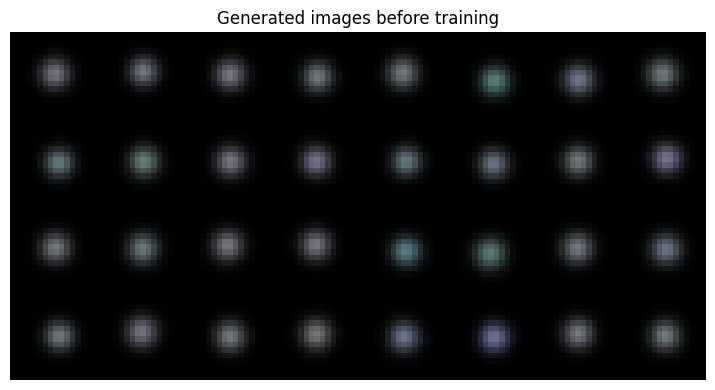

BlobGenerator(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=6, bias=True)
  )
)

In [49]:
G.eval()
with torch.no_grad():
    fake_before = G(fixed_z)

print("Untrained generated displayed standard deviation:", float(denormalize(fake_before).std()))
show_grid(fake_before, "Generated images before training", save_path=OUTPUT_DIR / "generated_before_training.png")
G.train()

## 9. Train

In [62]:
def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch

data_iter = infinite_loader(loader)

D_losses = []
G_losses = []
D_real_means = []
D_fake_means = []

start = time.time()

for step in range(1, TRAIN_STEPS + 1):
    real, _ = next(data_iter)
    real = real.to(device)
    B = real.shape[0]

    z = torch.randn(B, Z_DIM, device=device)

    with torch.no_grad():
        fake = G(z)

    real_scores = D(real)
    fake_scores = D(fake)

    loss_D = d_loss_lsgan(real_scores, fake_scores)

    opt_D.zero_grad(set_to_none=True)
    loss_D.backward()
    opt_D.step()

    z = torch.randn(B, Z_DIM, device=device)
    fake = G(z)
    fake_scores_for_G = D(fake)

    loss_G = g_loss_lsgan(fake_scores_for_G)

    opt_G.zero_grad(set_to_none=True)
    loss_G.backward()
    opt_G.step()

    D_losses.append(float(loss_D.detach().cpu()))
    G_losses.append(float(loss_G.detach().cpu()))
    D_real_means.append(float(real_scores.mean().detach().cpu()))
    D_fake_means.append(float(fake_scores.mean().detach().cpu()))

    if step == 1 or step % 100 == 0:
        print(
            f"step {step:04d}/{TRAIN_STEPS} | "
            f"D_loss={D_losses[-1]:.4f} | "
            f"G_loss={G_losses[-1]:.4f} | "
            f"D(real)={D_real_means[-1]:.3f} | "
            f"D(fake)={D_fake_means[-1]:.3f}"
        )

print(f"Training time: {time.time() - start:.2f} seconds")

step 0001/400 | D_loss=0.1112 | G_loss=0.5404 | D(real)=0.894 | D(fake)=0.374
step 0100/400 | D_loss=0.0943 | G_loss=0.2595 | D(real)=0.819 | D(fake)=0.202
step 0200/400 | D_loss=0.0881 | G_loss=0.3983 | D(real)=0.882 | D(fake)=0.291
step 0300/400 | D_loss=0.1129 | G_loss=0.2825 | D(real)=0.906 | D(fake)=0.326
step 0400/400 | D_loss=0.1066 | G_loss=0.4092 | D(real)=0.776 | D(fake)=0.241
Training time: 2.35 seconds


## 10. After training

The generated samples should now be visibly comparable to the real training-image family.

They are not meant to be copies. They should be new colored blobs drawn from the learned generator distribution.

Final generated displayed standard deviation: 0.14703112840652466


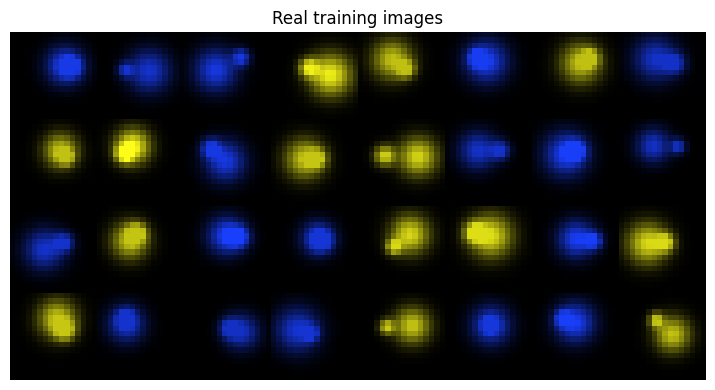

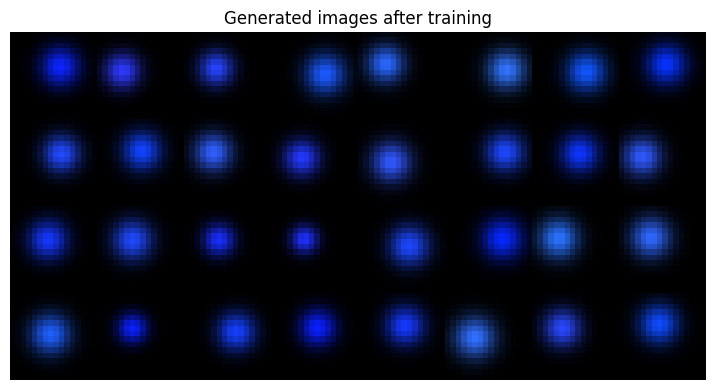

BlobGenerator(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=6, bias=True)
  )
)

In [63]:
G.eval()
with torch.no_grad():
    fake_after = G(fixed_z)

print("Final generated displayed standard deviation:", float(denormalize(fake_after).std()))

show_grid(real_batch[:32], "Real training images", save_path=OUTPUT_DIR / "real_training_images_again.png")
show_grid(fake_after, "Generated images after training", save_path=OUTPUT_DIR / "generated_after_training.png")
G.train()

## 11. Diagnostics

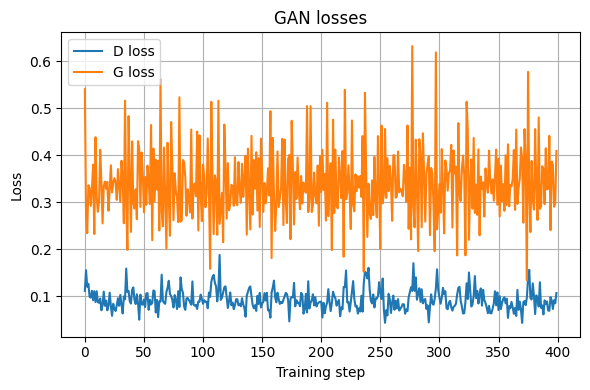

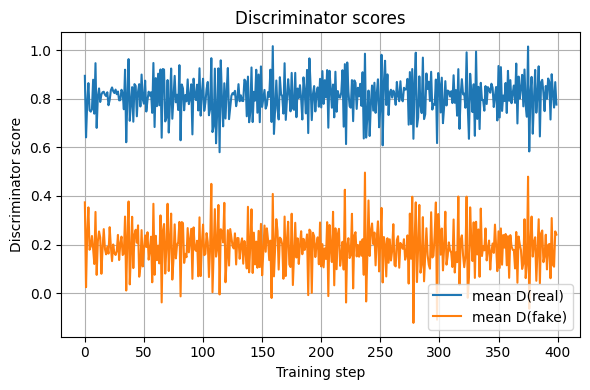

In [64]:
plt.figure(figsize=(6, 4))
plt.plot(D_losses, label="D loss")
plt.plot(G_losses, label="G loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN losses")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "losses.png", dpi=160)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(D_real_means, label="mean D(real)")
plt.plot(D_fake_means, label="mean D(fake)")
plt.xlabel("Training step")
plt.ylabel("Discriminator score")
plt.title("Discriminator scores")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scores.png", dpi=160)
plt.show()

## 12. Summary

This is a working GAN teaching demo:

$$
z\sim p_z,\qquad \widehat A=G_\theta(z),\qquad D_\phi(A)\in\mathbb R.
$$

The real images are colored blobs. The generated images after training are also colored blobs. This demonstrates the central GAN idea:

$$
p_G \approx p_{\mathrm{data}}.
$$

A full DCGAN on CIFAR-10 or other natural images needs far more training, larger models, and usually a GPU. It should not be expected to converge in a tiny smoke test.

## 13. Exercises
### Exercise 1
Final images need not to match any single training image, because GAN is learning distribution (paterns) not memorizing the exact picture.

$$
p_G \approx p_{\mathrm{data}}.
$$
The statement means that distribution learned by generator is becoming similar to distribution of real training data. In the images from this notebook we see that the images aren't exacly the same, but they have the same characteristics (blob shapes, color gradients). The generated-image grid shows that the GAN has learned to produce new images with the same properties. This visual similarity shows us that the generator has successfully approximated the underlying data distribution rather than memorizing specific examples.

### Exercise 2

After modifying the dataset to use only two colors and adding a second blob, the generator only partially learned the new data distribution. Generetor only uses one color from the modified palette, which suggests that the GAN collapsed toward a simpler solution. The generator did not learn the two-blob structure, since many generated samples still appeared to contain only one blob.

The training process remained relatively stable, loss curves fluctuated but did not diverge or explode. However, the generated image grids were more informative than the loss curves. Although the losses appeared stable, the visual outputs clearly showed that the generator failed to fully capture important properties of the modified dataset.

### Exercise 3

In [67]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset size:", len(dataset))

Dataset size: 50000
